In [20]:
pip install polars matplotlib seaborn pyarrow --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [21]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os
# Configuration du chemin de base vers vos données
BASE_PATH = os.path.expanduser("~/GreenDevOps/jobs_energy")

# Paramètres de style pour les graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [22]:
# %% [markdown]
# ## 2. Chargement des données (Ingestion Robuste)
# Cette fonction scanne vos dossiers et force les types numériques pour éviter les erreurs de schéma.

# %%
def load_and_fix_data(base_dir):
    all_summaries = []
    all_jobs = []
    float_cols = ["cpu_j", "ram_j", "sd_j", "nic_j", "gpu_j", "total_energy_j", "total_pipeline_energy_j"]
    
    # Parcourir les dossiers de projets (green_energy_org_...)
    project_folders = [f.path for f in os.scandir(base_dir) if f.is_dir()]
    
    for folder in project_folders:
        repo_name = os.path.basename(folder)
        
        # 1. Summaries (Pipelines totaux)
        summary_path = os.path.join(folder, "pipelines_total/pipeline_summary.csv")
        if os.path.exists(summary_path):
            df = pl.read_csv(summary_path, infer_schema_length=0) # Lire tout en String d'abord
            for col in float_cols:
                if col in df.columns:
                    df = df.with_columns(pl.col(col).str.replace(",", ".").cast(pl.Float64, strict=False))
            df = df.with_columns(pl.lit(repo_name).alias("_folder_ref"))
            all_summaries.append(df)
            
        # 2. Master DB (Détails des jobs)
        master_path = os.path.join(folder, "global_history/master_energy_database.csv")
        if os.path.exists(master_path):
            df_j = pl.read_csv(master_path, infer_schema_length=0)
            for col in float_cols:
                if col in df_j.columns:
                    df_j = df_j.with_columns(pl.col(col).str.replace(",", ".").cast(pl.Float64, strict=False))
            df_j = df_j.with_columns(pl.lit(repo_name).alias("_folder_ref"))
            all_jobs.append(df_j)

    return pl.concat(all_summaries, how="diagonal"), pl.concat(all_jobs, how="diagonal")

df_pipe, df_jobs = load_and_fix_data(BASE_PATH)
print(f"✅ Données chargées : {len(df_pipe)} pipelines et {len(df_jobs)} jobs détectés.")


✅ Données chargées : 61 pipelines et 392 jobs détectés.


### 3. Nettoyage et Réparation des Labels
### Nous réparons les colonnes vides (`project_name`, `category`) en utilisant le nom du répertoire racine.

In [29]:
def clean_data(df):
    # 1. Sécurité : On force les colonnes textuelles en String 
    # pour éviter le type 'Null' qui fait planter pl.when().otherwise()
    text_cols = ["project_name", "_folder_ref", "date"]
    for col in text_cols:
        if col in df.columns:
            df = df.with_columns(pl.col(col).cast(pl.String))

    # 2. Réparation des labels et conversion de date
    df = df.with_columns([
        # Correction du nom de projet
        pl.when(pl.col("project_name").is_null() | (pl.col("project_name") == ""))
          .then(
              pl.col("_folder_ref")
              .str.replace("green_energy_org_", "")
              .str.to_uppercase()
          )
          .otherwise(pl.col("project_name"))
          .alias("project_name"),
          
        # Conversion robuste de la date (gère les underscores et les espaces)
        pl.col("date")
          .str.replace("_", " ")
          .str.to_datetime("%Y-%m-%d %H:%M:%S", strict=False)
    ])

    # 3. Suppression des doublons et lignes sans ID
    return df.unique().drop_nulls(subset=["pipeline_id"])

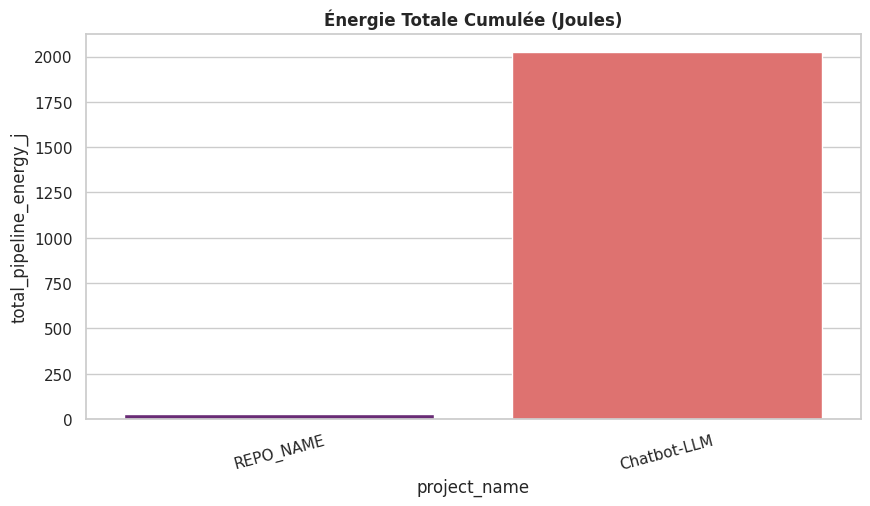

In [30]:
# %% [markdown]
# ## 4. Visualisation 1 : Consommation Totale par Projet
# Quel projet consomme le plus de ressources sur le long terme ?

# %%
plt.figure(figsize=(10, 5))
summary_energy = df_pipe.group_by("project_name").agg(pl.sum("total_pipeline_energy_j"))

# Correction : on ajoute hue="project_name" et legend=False pour éviter le FutureWarning
sns.barplot(
    data=summary_energy.to_pandas(), 
    x="project_name", 
    y="total_pipeline_energy_j", 
    hue="project_name", 
    palette="magma", 
    legend=False
)

plt.title("Énergie Totale Cumulée (Joules)", fontweight='bold')
plt.xticks(rotation=15)
plt.show()

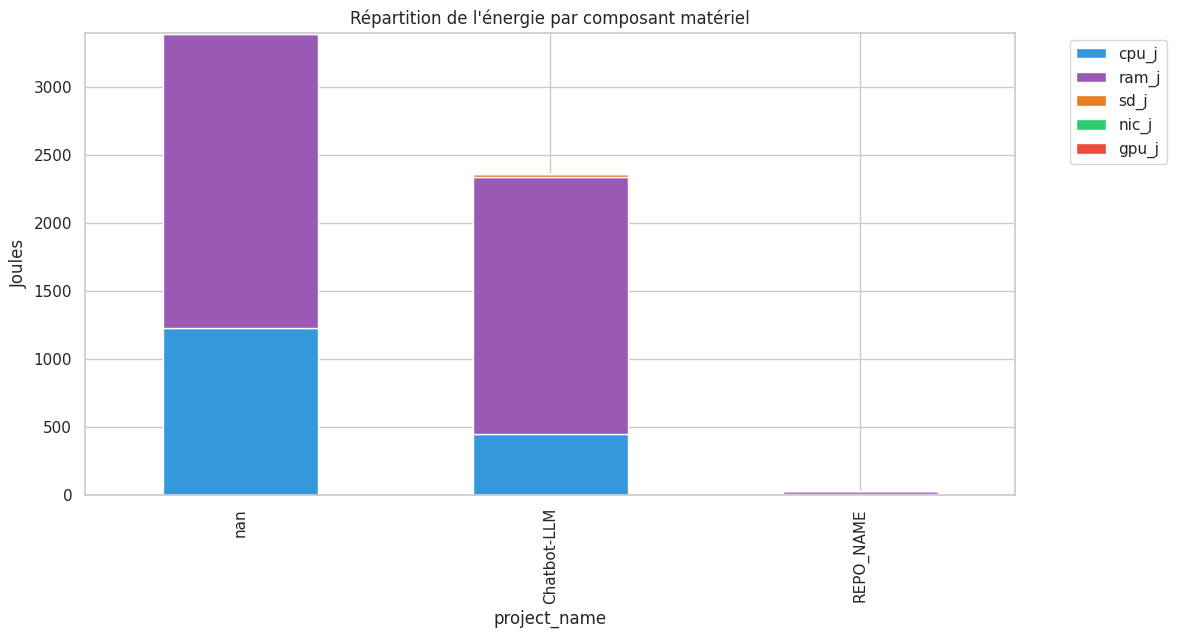

In [25]:
# %% [markdown]
# ## 5. Visualisation 2 : Répartition par Composants (CPU, RAM, NIC...)
# Est-ce que votre consommation vient du processeur ou des transferts réseau ?

# %%
comp_cols = ["cpu_j", "ram_j", "sd_j", "nic_j", "gpu_j"]
# Remplissage des valeurs nulles par 0 pour le calcul
df_comp_clean = df_jobs.with_columns([pl.col(c).fill_null(0) for c in comp_cols])
df_comp = df_comp_clean.group_by("project_name").agg([pl.sum(c) for c in comp_cols]).to_pandas()

df_comp.set_index("project_name")[comp_cols].plot(kind='bar', stacked=True, color=['#3498db', '#9b59b6', '#e67e22', '#2ecc71', '#e74c3c'])
plt.title("Répartition de l'énergie par composant matériel")
plt.ylabel("Joules")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

/tmp/ipykernel_80222/4122740233.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_jobs, y="job_name", x="avg_energy", palette="Reds_r")


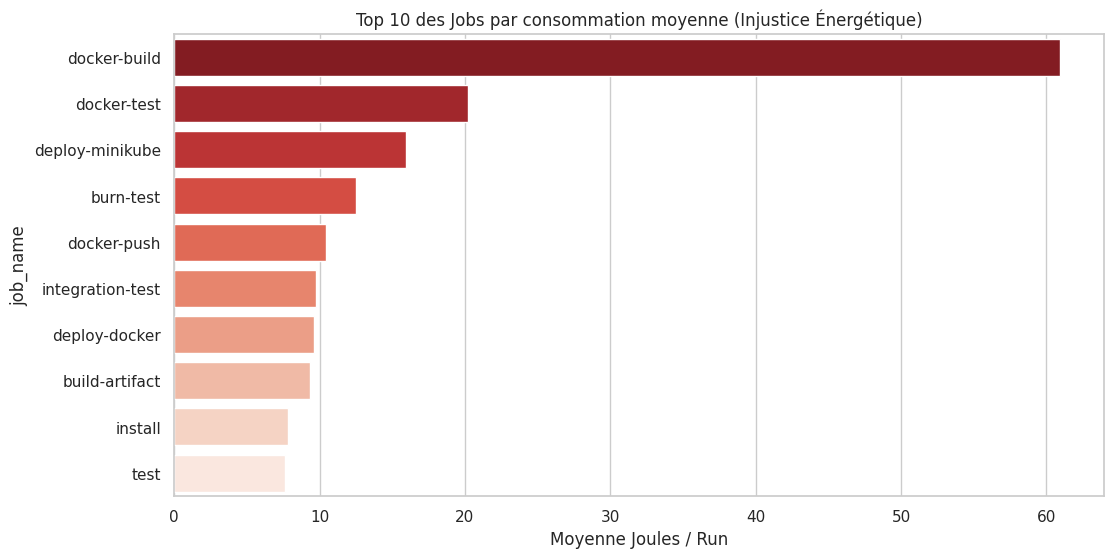

In [26]:

# %% [markdown]
# ## 6. Visualisation 3 : Top 10 des Jobs les plus coûteux
# Identifiez précisément les étapes du pipeline à optimiser en priorité.

# %%
top_jobs = df_jobs.group_by("job_name").agg(pl.mean("total_energy_j").alias("avg_energy"))
top_jobs = top_jobs.sort("avg_energy", descending=True).head(10).to_pandas()

sns.barplot(data=top_jobs, y="job_name", x="avg_energy", palette="Reds_r")
plt.title("Top 10 des Jobs par consommation moyenne (Injustice Énergétique)")
plt.xlabel("Moyenne Joules / Run")
plt.show()


In [31]:
print("--- CONSEILS D'OPTIMISATION ---")
# Trouver le job le plus lourd
worst_job = df_jobs.group_by("job_name").agg(pl.sum("total_energy_j")).sort("total_energy_j", descending=True).head(1)
name = worst_job['job_name'][0]
total = worst_job['total_energy_j'][0]

print(f"🚨 L'étape la plus énergivore au total est : {name} ({total:.2f} Joules)")
print(f"💡 Action suggérée : Si c'est un job de build, vérifiez le cache Docker. Si c'est du test, parallélisez ou réduisez les échantillons.")

--- CONSEILS D'OPTIMISATION ---
🚨 L'étape la plus énergivore au total est : docker-build (3107.05 Joules)
💡 Action suggérée : Si c'est un job de build, vérifiez le cache Docker. Si c'est du test, parallélisez ou réduisez les échantillons.
